# 2.TypeDict的使用
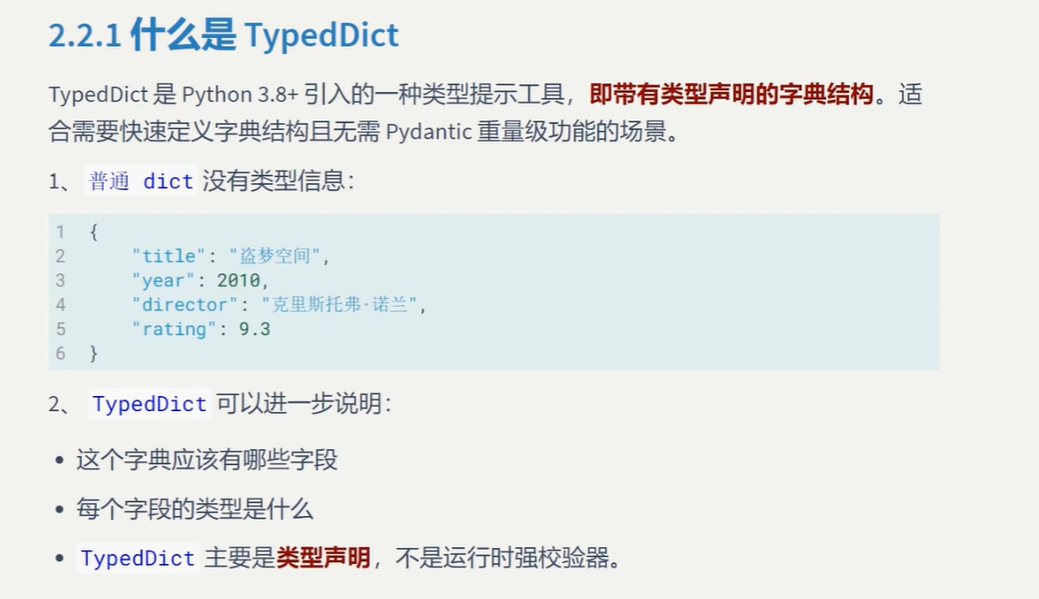

### 2.2.1举例1

In [3]:
from typing import List

from typing_extensions import TypedDict

class MovieDict(TypedDict):
    title: str
    year: int
    director: str
    rating: float

movie: MovieDict= {
    "title": "My first movie", # 如果你的字段和上面定义的字段不一样，就会有警告，程序黄色波浪线，但是不会抛异常
    "year": 2010,
    "director": "克里斯托弗·诺兰",
    "rating": 8.8,
}

print(movie)

{'title': 'My first movie', 'year': 2010, 'director': '克里斯托弗·诺兰', 'rating': 8.8}


In [8]:
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict, Annotated

# 创建模型实例
model = ChatOpenAI(
    model="mistral-nemo:latest",
    # model="dzgg/gemini-3-pro-preview:latest", # 这个案例用这个模型的效果挺好
    # model="mo-shakib/gemma4-e4b-uncensored:q4_k_m",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class MovieDict(TypedDict):
    title: Annotated[str, "电影名称"]
    year: Annotated[int, "上映年份，四位数"]
    director: Annotated[str, "导演"]
    rating: Annotated[float, "评分，满分10分，可以包含一位小数"]

smodel = model.with_structured_output(MovieDict)
result = smodel.invoke("请介绍一下《星际穿越》这部电影")
print(result)


{'title': '_星际穿越_', 'year': 2014, 'director': '克里斯托弗·诺兰', 'rating': 8.6}


## 举例2 嵌套结构

In [10]:
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict, Annotated
from typing import List
# 创建模型实例
model = ChatOpenAI(
    model="mistral-nemo:latest",
    # model="dzgg/gemini-3-pro-preview:latest", # 这个案例用这个模型的效果挺好
    # model="mo-shakib/gemma4-e4b-uncensored:q4_k_m",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class Actor(TypedDict):
    """演员信息"""
    name: Annotated[str,"演员姓名"]
    role: Annotated[str,"饰演的角色"]


class MovieDict(TypedDict):
    title: Annotated[str, "电影名称"]
    year: Annotated[int, "上映年份，四位数"]
    director: Annotated[str, "导演"]
    rating: Annotated[float, "评分，满分10分，可以包含一位小数"]
    cast: Annotated[List[Actor],"演员列表"]

smodel = model.with_structured_output(MovieDict)
result = smodel.invoke("请介绍一下《星际穿越》这部电影")
print(result)


{'title': '星际穿越 (Interstellar)', 'year': 2014, 'director': 'Christopher Nolan', 'cast': [{'name': 'Matthew McConaughey', 'role': ' Coop'}, {'name': 'Anne Hathaway', 'role': 'Brand'}, {'name': 'Jessica Chastain', 'role': 'Murph adult'}, {'name': 'Mackenzie Foy', 'role': 'Murph'}]}


### 举例3 ...的使用

In [11]:
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict, Annotated
from typing import List
# 创建模型实例
model = ChatOpenAI(
    model="mistral-nemo:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class MovieDict(TypedDict):
    title: Annotated[str,..., "电影名称"]  # ...的意思是必须要填写
    year: Annotated[int, ...,"上映年份，四位数"]
    director: Annotated[str, ...,"导演"]
    rating: Annotated[float, ...,"评分，满分10分，可以包含一位小数"]

smodel = model.with_structured_output(MovieDict)
result = smodel.invoke("根据这段话抽取盗梦空间的信息，不包含的信息可以留空： 盗梦空间在2010年上映，导演是克里斯托弗.诺兰")
print(result)

{'title': '盗梦空间', 'year': 2010, 'director': '克里斯托弗·诺兰', 'rating': 0}


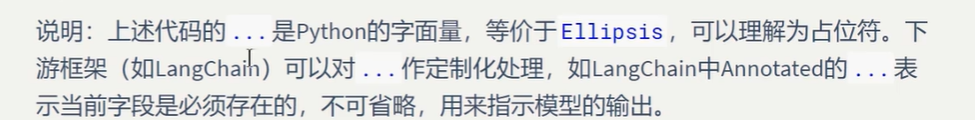